In [1]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

import matplotlib.pyplot as plt

import joblib

In [2]:
X_train = pd.read_csv("../data/processed/X_train.csv")

X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")

y_test = pd.read_csv("../data/processed/y_test.csv")

In [3]:
X_train.head()

,num__CreditScore,num__Age,num__Tenure,num__Balance,num__NumOfProducts,num__HasCrCard,num__IsActiveMember,num__EstimatedSalary,cat__Geography_Germany,cat__Geography_Spain,cat__Gender_Male
0,1.058568,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,0.0,0.0,1.0
1,0.913626,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,1.0,0.0,1.0
2,1.079274,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,1.0,0.0,0.0
3,-0.929207,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,0.0,0.0,1.0
4,0.427035,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,1.0,0.0,1.0


In [4]:
print("X_train :", X_train.shape)
print("X_test :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

X_train : (8000, 11)
X_test : (2000, 11)
y_train : (8000, 1)
y_test : (2000, 1)


# Logistic Regression

The first baseline model used in this project is Logistic Regression.

This model will serve as a benchmark for comparing future machine learning models.

In [5]:
lr_model = LogisticRegression(random_state = 42)

In [6]:
lr_model.fit(X_train, y_train.values.ravel())

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [7]:
y_pred = lr_model.predict(X_test)

In [8]:
y_pred_prob = lr_model.predict_proba(X_test)[:,1]

In [9]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.808


In [10]:
y_pred

array([0, 0, 0, ..., 1, 0, 0], shape=(2000,))

In [11]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 11)
(2000, 11)
(8000, 1)
(2000, 1)


In [12]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[1540   53]
 [ 331   76]]


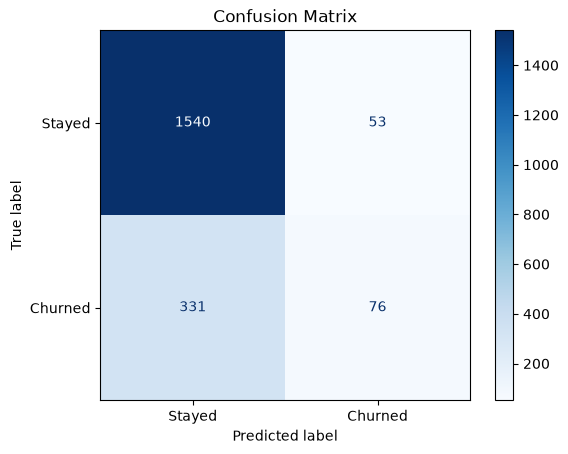

In [15]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Churned'])

disp.plot(cmap='Blues',)
plt.title("Confusion Matrix")
plt.show()

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1593
           1       0.59      0.19      0.28       407

    accuracy                           0.81      2000
   macro avg       0.71      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



In [20]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test,y_pred_prob)

print(f"Precision : {precision:.4f}")
print(f"Recall  : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"Roc_Auc : {roc_auc:.4f}")



Precision : 0.5891
Recall  : 0.1867
F1 Score : 0.2836
Roc_Auc : 0.7748


## Model Performance Analysis

- Logistic Regression achieved an accuracy of **80.8%**.

- However, the dataset is moderately imbalanced (approximately 80% stayed vs 20% churned), so accuracy alone is not a sufficient evaluation metric.

- The model correctly identified **1540** customers who stayed.

- The model correctly detected only **76** churned customers while missing **331** churned customers.

- The recall for the churn class is only **18.7%**, indicating that the model fails to identify most customers who are likely to churn.

- Precision is **58.9%**, meaning that when the model predicts churn, it is correct around 59% of the time.

- The ROC-AUC score of **0.775** indicates that the model has reasonable ranking ability, but the default classification threshold is not optimal.

- Overall, Logistic Regression serves as a good baseline model, but additional models and optimization techniques are required to improve churn detection.

# Improving the performence of the model

In [21]:
lr_model_balanced = LogisticRegression(
    random_state=42,
    class_weight="balanced"
)

lr_model_balanced.fit(
    X_train,
    y_train.values.ravel()
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default

In [22]:
y_pred_balanced = lr_model_balanced.predict(X_test)
y_pred_prob_balanced = lr_model_balanced.predict_proba(X_test)[:,1]

In [23]:
accuracy_balanced = accuracy_score(
    y_test,
    y_pred_balanced
)

precision_balanced = precision_score(
    y_test,
    y_pred_balanced
)

recall_balanced = recall_score(
    y_test,
    y_pred_balanced
)

f1_balanced = f1_score(
    y_test,
    y_pred_balanced
)

roc_auc_balanced = roc_auc_score(
    y_test,
    y_pred_prob_balanced
)

In [24]:
print(f"Accuracy : {accuracy_balanced:.4f}")

print(f"Precision : {precision_balanced:.4f}")

print(f"Recall : {recall_balanced:.4f}")

print(f"F1 Score : {f1_balanced:.4f}")

print(f"ROC AUC : {roc_auc_balanced:.4f}")

Accuracy : 0.7140
Precision : 0.3878
Recall : 0.7002
F1 Score : 0.4991
ROC AUC : 0.7772


In [25]:
print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1593
           1       0.39      0.70      0.50       407

    accuracy                           0.71      2000
   macro avg       0.65      0.71      0.65      2000
weighted avg       0.80      0.71      0.74      2000



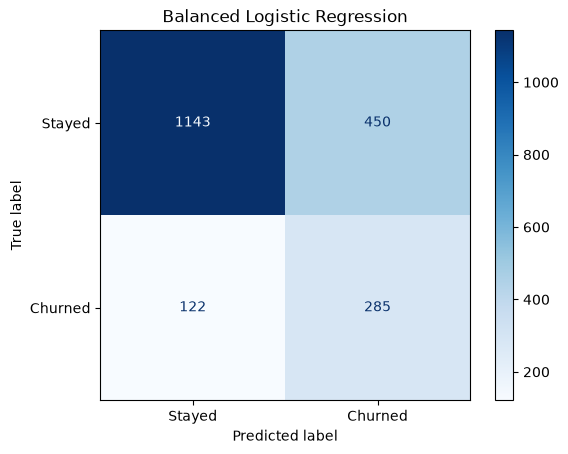

In [26]:
cm = confusion_matrix(
    y_test,
    y_pred_balanced
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stayed", "Churned"]
)

disp.plot(cmap="Blues")

plt.title("Balanced Logistic Regression")

plt.show()

In [27]:
print(cm)

[[1143  450]
 [ 122  285]]


## Logistic Regression Improvement

To improve the model's ability to detect customer churn, Logistic Regression was retrained using `class_weight="balanced"`.

### Key Findings

- Accuracy decreased from **80.8%** to **71.4%**.
- Recall improved significantly from **18.7%** to **70.0%**.
- F1-score increased from **28.4%** to **49.9%**.
- ROC-AUC remained stable and showed a slight improvement.

### Business Interpretation

The balanced model identifies a much larger proportion of churned customers, making it more suitable for customer retention strategies where missing potential churners is costly.

However, this comes at the expense of lower precision and more false positive predictions, which may increase the cost of retention campaigns.